Loaded audio: 72576 samples, 24000 Hz


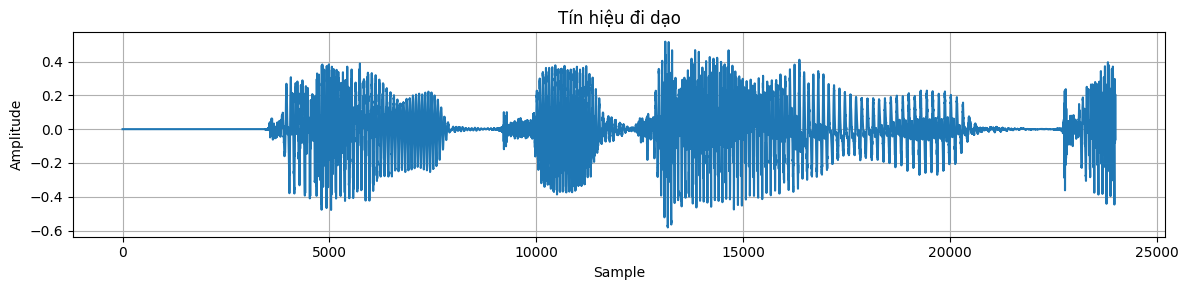


Tín hiệu gốc:


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import librosa

# Load audio file or create test signal
try:
    x, Fs = librosa.load('tenki.mp3', sr=None, mono=True)
    print(f"Loaded audio: {len(x)} samples, {Fs} Hz")
except:
    Fs = 8000
    duration = 3
    t = np.linspace(0, duration, int(Fs * duration))
    
    x = (np.sin(2*np.pi*440*t) * np.exp(-t/0.5) +
         np.sin(2*np.pi*554*t) * np.exp(-(t-0.3)/0.5) * (t > 0.3) +
         np.sin(2*np.pi*659*t) * np.exp(-(t-0.6)/0.5) * (t > 0.6))
    
    x = x / np.max(np.abs(x))
    print(f"Tạo test signal: {len(x)} samples, {Fs} Hz")

plt.figure(figsize=(12, 3))
plt.plot(x[:Fs])
plt.title('Tín hiệu đi dạo')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nTín hiệu gốc:")
Audio(x, rate=Fs)

τ = 100.0 ms, a = 0.7, D = 2400 samples
y[n] = 0.7·y[n - 2400] + x[n - 2400]


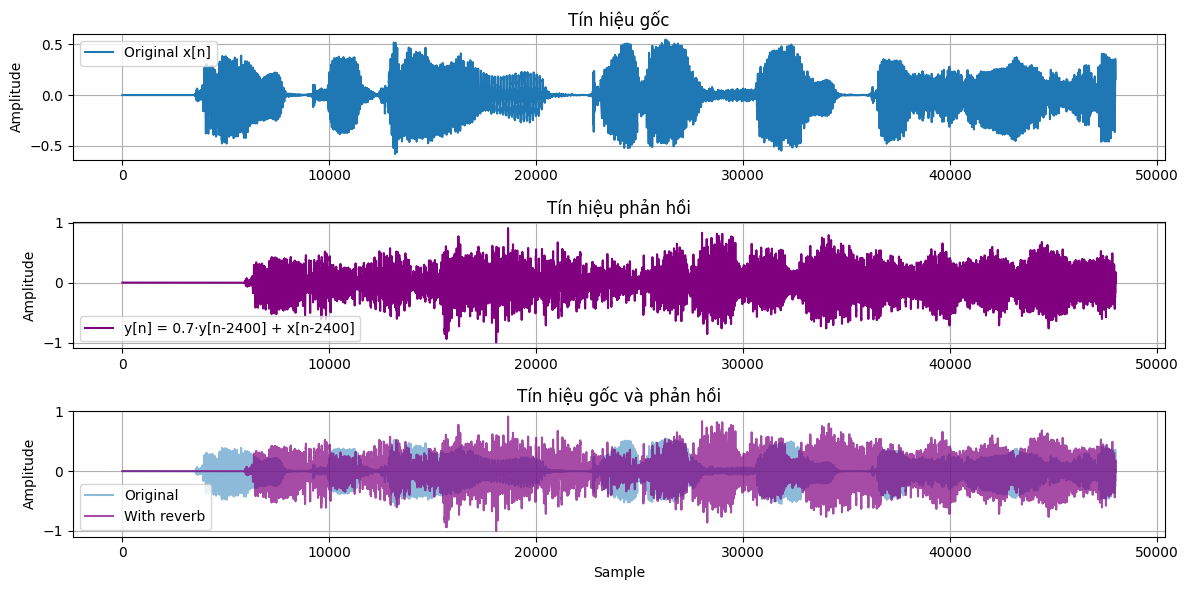

Nhận thấy 2400 mẫu (100.0 ms) bị trễ trong tin hiệu trước khi phản hồi bắt đầu ảnh hưởng.



In [9]:
# y[n] = ay[n - D] + x[n - D]

tau = 0.100  
a = 0.7      
D = int(tau * Fs)

print(f"τ = {tau*1000} ms, a = {a}, D = {D} samples")
print(f"y[n] = {a}·y[n - {D}] + x[n - {D}]")

y = np.zeros(len(x))

buffer_x = np.zeros(D)

for n in range(len(x)):
    idx = n % D
    x_delayed = buffer_x[idx]
    
    if n >= D:
        y_delayed = y[n - D]
    else:
        y_delayed = 0
    
    y[n] = a * y_delayed + x_delayed
    
    buffer_x[idx] = x[n]

y = y / np.max(np.abs(y))

plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.plot(x[:2*Fs], label='Original x[n]')
plt.title('Tín hiệu gốc')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(y[:2*Fs], label=f'y[n] = {a}·y[n-{D}] + x[n-{D}]', color='purple')
plt.title('Tín hiệu phản hồi')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(x[:2*Fs], alpha=0.5, label='Original')
plt.plot(y[:2*Fs], alpha=0.7, label='With reverb', color='purple')
plt.title('Tín hiệu gốc và phản hồi')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Nhận thấy {D} mẫu ({tau*1000} ms) bị trễ trong tin hiệu trước khi phản hồi bắt đầu ảnh hưởng.")
print("")
Audio(y, rate=Fs)

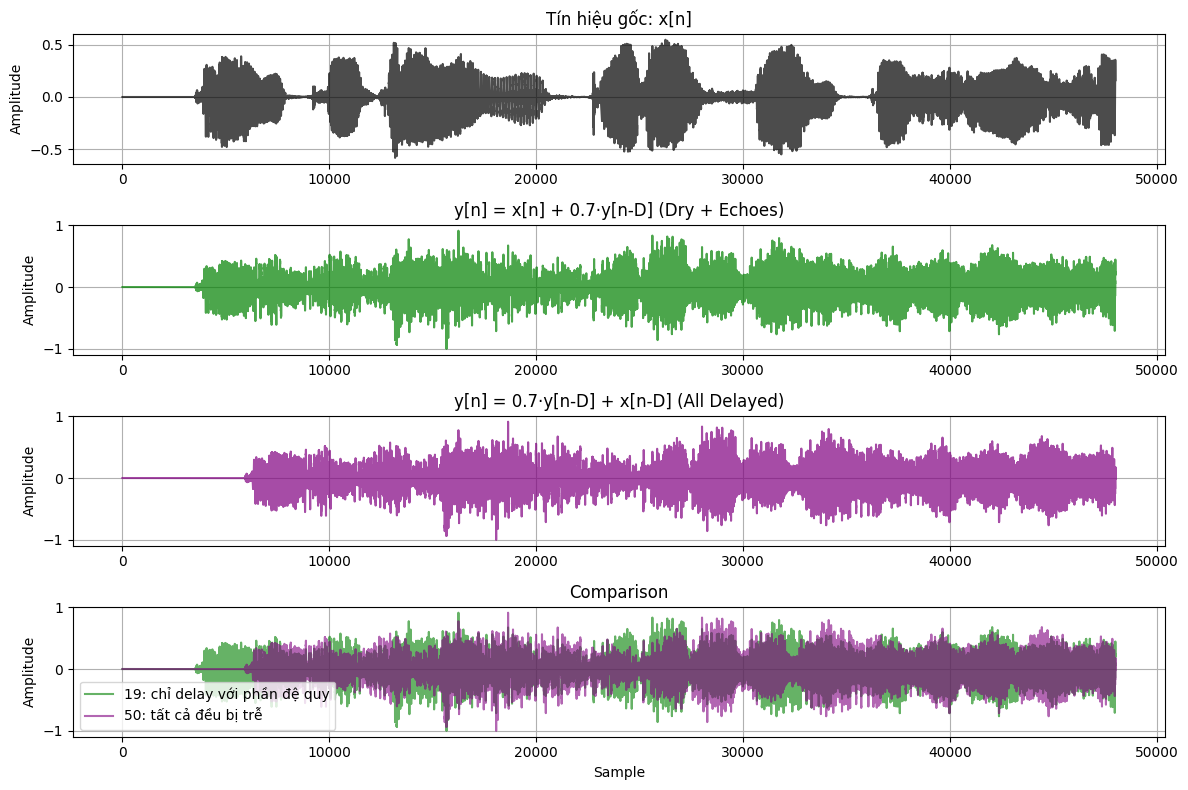


ss:
19 (dry + echoes):



50 (all delayed):


In [11]:
#y[n] = x[n] + ay[n - D]
y_p19 = np.zeros(len(x))
for n in range(len(x)):
    if n < D:
        y_p19[n] = x[n]
    else:
        y_p19[n] = x[n] + a * y_p19[n - D]

y_p19 = y_p19 / np.max(np.abs(y_p19))

plt.figure(figsize=(12, 8))

# gốc
plt.subplot(4, 1, 1)
plt.plot(x[:2*Fs], color='black', alpha=0.7)
plt.title('Tín hiệu gốc: x[n]')
plt.ylabel('Amplitude')
plt.grid(True)

# 19
plt.subplot(4, 1, 2)
plt.plot(y_p19[:2*Fs], color='green', alpha=0.7)
plt.title('y[n] = x[n] + 0.7·y[n-D] (Dry + Echoes)')
plt.ylabel('Amplitude')
plt.grid(True)

# 50
plt.subplot(4, 1, 3)
plt.plot(y[:2*Fs], color='purple', alpha=0.7)
plt.title('y[n] = 0.7·y[n-D] + x[n-D] (All Delayed)')
plt.ylabel('Amplitude')
plt.grid(True)

# Overlay
plt.subplot(4, 1, 4)
plt.plot(y_p19[:2*Fs], label='19: chỉ delay với phần đệ quy', color='green', alpha=0.6)
plt.plot(y[:2*Fs], label='50: tất cả đều bị trễ', color='purple', alpha=0.6)
plt.title('Comparison')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\nss:")
print("19 (dry + echoes):")
display(Audio(y_p19, rate=Fs))
print("\n50 (all delayed):")
display(Audio(y, rate=Fs))